# PROACT in bulk DNase-seq data

This tutorial demonstrates PROACT on bulk DNase-seq data from HCT116 and HEK293T cells. Genome-wide motif sites were identified with FIMO and intersected with the central 200 bp of DNase-accessible peaks using bedtools. Target TFs were extracted from bioplex database which stored experimental PPIs of [HCT116](https://bioplex.hms.harvard.edu/data/BioPlex_HCT116_Network_5.5K_Dec_2019.tsv) and [HEK293T](https://bioplex.hms.harvard.edu/data/BioPlex_293T_Network_10K_Dec_2019.tsv) cells. Cell-line expression data were used to define expressed TFs.

> **Reproducibility note:** The code-cell outputs shown in this notebook are preserved from the original analysis run. Local file paths reflect the original analysis environment and should be updated before rerunning the notebook.

## Load preprocessed bulk inputs

In [1]:
# ==============================================================================
# Bulk DNase-seq application
# ==============================================================================

# DNase-seq data for HCT116 and HEK293T were downloaded from ENSEMBL.
# Cell-line-expressed TFs were defined using expression data downloaded from ENCODE.

cell_lines <- c("HCT116", "HEK293T")
peak_files <- c(HCT116 = "examples/bulk/HCT116.200.1e-04.txt",HEK293T = "examples/bulk/HEK293T.200.1e-04.txt")
target_tf_files <- c(HCT116 = "examples/bulk/HCT116.TFs.txt",HEK293T = "examples/bulk/HEK293T.TFs.txt")
expressed_tf_files <- c(HCT116 = "examples/bulk/HCT116.expressedTFs.txt",HEK293T = "examples/bulk/HEK293T.expressedTFs.txt")

bulk_inputs <- lapply(cell_lines, function(cell_line) {
    peak_motif <- read.table(peak_files[[cell_line]], header = TRUE, sep = "\t",stringsAsFactors = FALSE, check.names = FALSE)
    target_tfs <- read.table(target_tf_files[[cell_line]], header = FALSE,stringsAsFactors = FALSE)[, 1]
    expressed_tfs <- read.table(expressed_tf_files[[cell_line]], header = FALSE,stringsAsFactors = FALSE)[, 1]
    list(peak_motif = peak_motif,target_tfs = target_tfs,expressed_tfs = expressed_tfs)})

names(bulk_inputs) <- cell_lines

## Run PROACT

For each cell line, all DNase-accessible peaks were used to construct the peak-by-TF matrix. TFs without detectable expression in the corresponding ENCODE expression dataset were excluded, and PROACT inference was restricted to expressed TFs.

In [2]:
# ==============================================================================
# Run PROACT
# ==============================================================================

library(PROACT)

# 1. Build the TF prior matrix
motif_anno_file <- system.file("extdata", "metadata.tsv", package = "PROACT")
motif_anno <- read.table(motif_anno_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
# Remove redundant motifs using the default PROACT motif list
remove_motifs <- get("DEFAULT_REMOVE_MOTIFS", envir = asNamespace("PROACT"))
motif_anno <- motif_anno[!motif_anno$motif_id %in% remove_motifs, ]
jaspar_tfs <- unique(motif_anno$tf_name)

prior_mat <- build_prior(
    jaspar_tfs,
    ppi_dir = "data/PPI_data/human"
)

# 2. Run PROACT for each cell line
proact_results <- lapply(cell_lines, function(cell) {
    # Retain peaks on chr1-22 and chrX
    da_peaks <- bulk_inputs[[cell]]$peak_motif$peakID
    keep_chr <- c(paste0("chr", 1:22), "chrX")
    da_peaks <- da_peaks[sub("_.*$", "", da_peaks) %in% keep_chr]

    peak_tf <- prepare_peak_tf_matrix(
        peak_motif_mat = bulk_inputs[[cell]]$peak_motif,
        da_peaks = da_peaks,
        filter_expr = TRUE,
        expr_tfs = bulk_inputs[[cell]]$expressed_tfs
    )
    
    result <- run_PROACT(
        peak_tf_matrix = peak_tf,
        prior_mat = prior_mat,
        target_tfs = bulk_inputs[[cell]]$target_tfs,
        ncores = 12
    )

    list(peak_tf = peak_tf, result = result)
})

names(proact_results) <- cell_lines

Loading PPI databases ...

Block1 pairs: 1870

Block2 pairs: 3626


Preparing Peak x TF matrix


After peak filtering: 66967 peaks

Removed 37 redundant motif columns

Using minimum motif count = 5

524 TFs retained

370 TFs retained after expression filtering

Final matrix: 66967 peaks x 370 TFs

370 TFs used for priority lasso

72 target TFs retained for modeling



  |                                                                      |   0%

TEAD2: 366 TFs as predictors
TEAD2:19:347




  |=                                                                     |   1%

ATF2: 363 TFs as predictors
ATF2:18:9:336




...

  |===================================================================== |  99%

POU5F1: 490 TFs as predictors
POU5F1:19:3:468




  |======================================================================|  99%

CUX1: 494 TFs as predictors
CUX1:7:30:457




  |======================================================================| 100%



In [3]:
pair_results <- lapply(proact_results, `[[`, "result")
head(pair_results[['HCT116']])

,TF1,TF2,beta,Cluster1,Cluster2,prior,pairs
,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>
1,ATF2,CREB3,1.6882897,AC0155,AC0024,0,ATF2_CREB3
2,ATF2,NR2F1,1.1030394,AC0155,AC0165,0,ATF2_NR2F1
3,ATF2,ATF4,0.6780135,AC0155,AC0154,1,ATF2_ATF4
4,ATF2,THRA,0.5509845,AC0155,AC0022,0,ATF2_THRA
5,ATF2,HOXA4,0.5039258,AC0155,AC0009,0,ATF2_HOXA4
6,ATF2,DBP,0.4946534,AC0155,AC0154,0,ATF2_DBP


## Analyze TF pair grammar

In [5]:
# TF grammar
# motif positions
library(GenomicRanges)
motif_gr_list <- readRDS("examples/bulk/HCT116_motif_gr_list_p1e-4.rds")
keep_chr <- c(paste0("chr", 1:22),"chrX")
motif_gr_list <- lapply(motif_gr_list,function(gr){gr[as.character(seqnames(gr)) %in% keep_chr]})
motif_gr_list <- motif_gr_list[sapply(motif_gr_list,length) > 0]

head(motif_gr_list,3)

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics

Warning message:
“package ‘generics’ was built under R version 4.7.0”

Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The followi

$MA0003.5
GRanges object with 17959 ranges and 7 metadata columns:
          seqnames            ranges strand |          TF     score    pvalue
             <Rle>         <IRanges>  <Rle> | <character> <numeric> <numeric>
      [1]     chr1       29410-29418      + |    MA0003.5   12.3388  2.66e-05
      [2]     chr1       36635-36643      + |    MA0003.5   13.7355  1.02e-05
      [3]     chr1       38807-38815      - |    MA0003.5   11.5124  4.31e-05
      [4]     chr1     199926-199934      + |    MA0003.5   12.3388  2.66e-05
      [5]     chr1     827427-827435      + |    MA0003.5   12.3306  2.75e-05
      ...      ...               ...    ... .         ...       ...       ...
  [17955]    chr22 50628214-50628222      - |    MA0003.5   10.5207  7.61e-05
  [17956]    chr22 50628276-50628284      - |    MA0003.5   17.2066  1.30e-06
  [17957]    chr22 50656557-50656565      + |    MA0003.5   12.7190  2.25e-05
  [17958]    chr22 50783681-50783689      - |    MA0003.5   11.6116  4.09e-

In [6]:
df_pair <- pair_results[['HCT116']]
pairs <- df_pair[order(df_pair$beta,decreasing = T),][1:200,'pairs']

# detailed grammar features
pair_grammar <- find_grammar(motif_gr_list = motif_gr_list,pairs = pairs,strategy = 'best')

# summary
grammar_stats <- analyze_tf_grammar(
    pair_grammar,
    dist_bin = 5,
    min_count = 50
)

grammar_df <- summarize_tf_grammar(
    grammar_stats,
    spacing_metric = "edge",
    min_count = 50
)

# add motif-overlap proportion
overlap_df <- do.call(rbind, lapply(names(pair_grammar), function(pair) {
    df <- pair_grammar[[pair]]
    if(is.null(df) || nrow(df) == 0) return(NULL)
    data.frame(pair = pair, overlap_prop = mean(df$edge_distance <= 0, na.rm = TRUE))
}))

grammar_df <- merge(grammar_df, overlap_df, by = "pair", all.x = TRUE)

# add prior annotation to grammar results
prior_anno <- df_pair[, c("pairs", "prior")]
colnames(prior_anno)[1] <- "pair"
grammar_df <- merge(grammar_df, prior_anno, by = "pair", all.x = TRUE)
grammar_df$Category <- ifelse(grammar_df$prior > 0,"Prior-supported","No prior")

## Visualize the grammar landscape

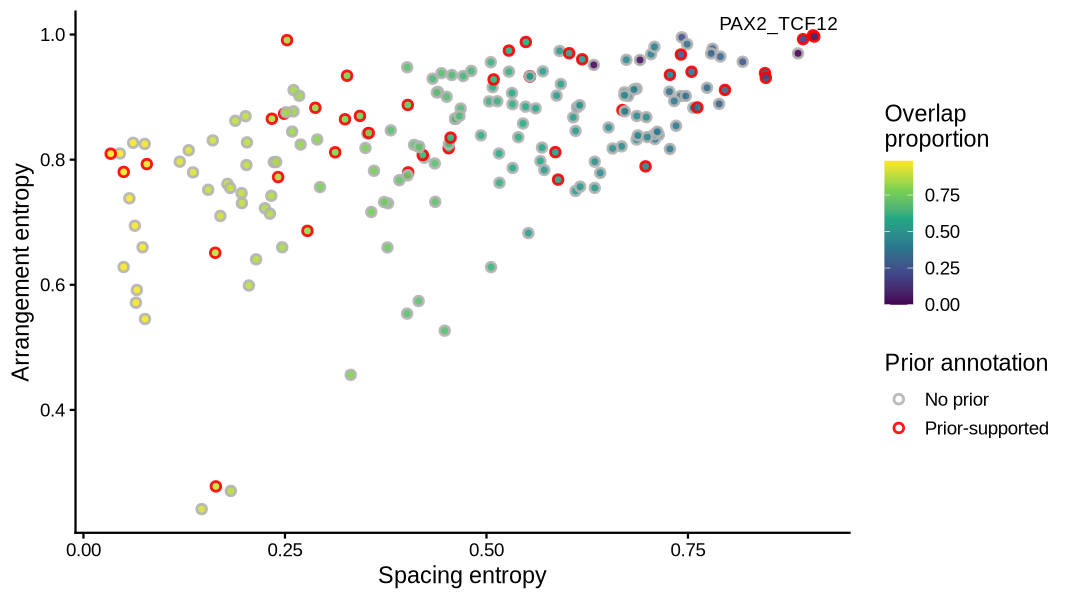

In [7]:
library(ggplot2)
options(repr.plot.width = 9, repr.plot.height = 5)
p <- ggplot(
    grammar_df,
    aes(x = spacing_entropy,y = arrangement_entropy,
        fill = overlap_prop,color = Category)) +
    geom_point(shape = 21, stroke = 1.2, alpha = 0.9) +
    scale_size_continuous(range = c(3, 9), name = "Motif-pair count") +
    scale_fill_viridis_c(name = "Overlap\nproportion") +
    scale_color_manual(values = c("Prior-supported" = "red","No prior" = "grey70"),name = "Prior annotation") +
    theme_classic(base_size = 14) +
    labs(x = "Spacing entropy",y = "Arrangement entropy")
label_df <- subset(grammar_df, pair == "PAX2_TCF12")
p + geom_text(data = label_df,aes(label = pair),color = "black",size = 4,hjust = 0.8,vjust = -0.5) 

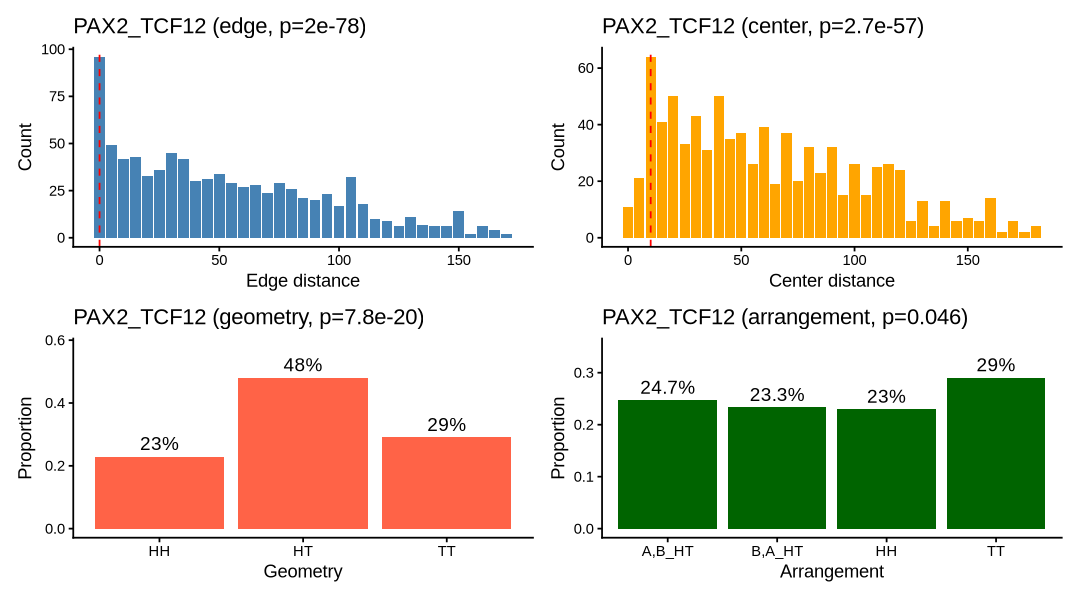

In [8]:
plot_tf_grammar(grammar_stats, pair = "PAX2_TCF12")

### Session Information

In [9]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Rocky Linux 9.7 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /home/handongmei/miniconda3/envs/R4.4/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
[1] ggplot2_4.0.2        GenomicRanges_1.56.2 GenomeInfoDb_1.40.1 
[4] IRanges_2.38.1       S4Vectors_0.42.1     BiocGenerics_0.56.0 
[7] generics_0.1.4       PROACT_0.1.0        

loaded via a namespace (and